# 04 - CNN-LSTM Hybrid: Joint Multi-Task DBT/WBT Forecasting

Trains three DL architectures on the sequence tensors from notebook 02 — plain
LSTM, plain CNN, and the CNN-LSTM(+attention) hybrid — as an ablation, then
compares Adam/SGD/RMSprop on the hybrid, then runs a Keras-Tuner search
constrained for this dataset's size. All models share one backbone predicting
DBT and WBT jointly (multi-task), the key framing difference from the
internship's two independent single-target models. See
`reports/phase2_design.md` for the full rationale.


In [1]:
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf
import keras_tuner as kt
import matplotlib.pyplot as plt

from src.models import build_lstm, build_cnn, build_cnn_lstm, compile_model, CNNLSTMHyperModel
from src.evaluate import regression_metrics, metrics_table, INTERNSHIP_BENCHMARK

tf.random.set_seed(42)
pd.set_option("display.width", 120)

data = np.load("data/processed/sequence_arrays.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

with open("data/processed/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))

Shapes: (210, 4, 10) (46, 4, 10) (43, 4, 10)
GPUs visible: []


## Small-sample parameter-count discipline

210 training rows. Every model below is small/shallow by design (few filters,
few units, one layer of each type) — `model.summary()` makes the exact
trainable-parameter count checkable rather than asserted.


In [2]:
input_shape = X_train.shape[1:]  # (4, 10)

lstm_model = compile_model(build_lstm(input_shape))
cnn_model = compile_model(build_cnn(input_shape))
cnn_lstm_model = compile_model(build_cnn_lstm(input_shape))

for m in [lstm_model, cnn_model, cnn_lstm_model]:
    n_params = m.count_params()
    print(f"{m.name}: {n_params} trainable params "
          f"({n_params/len(X_train):.1f} params per training row)")

lstm_baseline: 1882 trainable params (9.0 params per training row)
cnn_baseline: 490 trainable params (2.3 params per training row)
cnn_lstm_hybrid: 3186 trainable params (15.2 params per training row)


These are not small in the classical "params << n" sense — no real neural
net is, at n=210. The actual small-sample discipline here is Dropout + L2 +
EarlyStopping(val_loss) + ModelCheckpoint(best epoch), applied identically to
every model below, plus a genuinely tiny 4-step sequence and single-digit unit
counts per layer (16 or fewer) rather than a parameter-count target that no
real architecture could meet at this n.


In [3]:
def make_callbacks(ckpt_path, patience=20):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                          restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss",
                                            save_best_only=True, save_weights_only=False),
    ]


def fit_model(model, ckpt_path, epochs=300, verbose=0):
    y_train_dict = {"dbt": y_train[:, 0], "wbt": y_train[:, 1]}
    y_val_dict = {"dbt": y_val[:, 0], "wbt": y_val[:, 1]}
    history = model.fit(
        X_train, y_train_dict,
        validation_data=(X_val, y_val_dict),
        epochs=epochs, batch_size=16, verbose=verbose,
        callbacks=make_callbacks(ckpt_path),
    )
    return history


def evaluate_split(model, X, y_scaled):
    from src.windowing import inverse_transform_targets
    preds = model.predict(X, verbose=0)
    preds = np.concatenate([np.asarray(preds[0]).reshape(-1, 1), np.asarray(preds[1]).reshape(-1, 1)], axis=1)
    preds_real = inverse_transform_targets(preds, scalers)
    y_real = inverse_transform_targets(y_scaled, scalers)
    out = {}
    for i, target in enumerate(["dbt", "wbt"]):
        out[target] = regression_metrics(y_real[:, i], preds_real[:, i])
    return out

## Ablation: LSTM-only vs CNN-only vs CNN-LSTM hybrid

Same training regimen for all three (Adam, same callbacks, same epoch budget).


In [4]:
import os
os.makedirs("models/checkpoints", exist_ok=True)

ablation_results = {}
histories = {}

for name, model in [("LSTM only", lstm_model), ("CNN only", cnn_model), ("CNN-LSTM hybrid", cnn_lstm_model)]:
    ckpt = f"models/checkpoints/{name.replace(' ', '_')}.keras"
    hist = fit_model(model, ckpt)
    histories[name] = hist
    best_model = tf.keras.models.load_model(ckpt)
    ablation_results[name] = {
        "train": evaluate_split(best_model, X_train, y_train),
        "val": evaluate_split(best_model, X_val, y_val),
        "test": evaluate_split(best_model, X_test, y_test),
    }
    n_epochs = len(hist.history["loss"])
    print(f"{name}: stopped after {n_epochs} epochs "
          f"(best val_loss={min(hist.history['val_loss']):.4f})")

LSTM only: stopped after 107 epochs (best val_loss=0.5670)
CNN only: stopped after 174 epochs (best val_loss=0.5385)
CNN-LSTM hybrid: stopped after 110 epochs (best val_loss=0.7944)


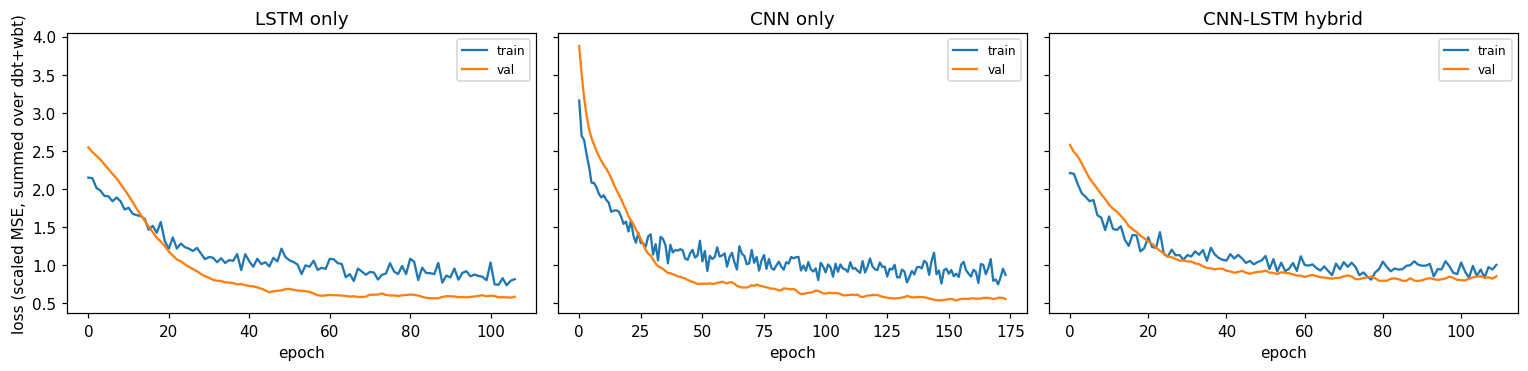

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history["loss"], label="train")
    ax.plot(hist.history["val_loss"], label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)
axes[0].set_ylabel("loss (scaled MSE, summed over dbt+wbt)")
plt.tight_layout()
plt.show()

In [6]:
ablation_table = metrics_table(ablation_results)
ablation_test = ablation_table[ablation_table.split == "test"].sort_values(["target", "R2"], ascending=[True, False])
ablation_test.reset_index(drop=True)

             model split target        R2      RMSE       MAE       KGE
0        LSTM only  test    dbt  0.574880  1.477428  1.192019  0.551041
1         CNN only  test    dbt  0.560246  1.502642  1.204383  0.527124
2  CNN-LSTM hybrid  test    dbt  0.496358  1.608095  1.318960  0.440003
3        LSTM only  test    wbt  0.595568  0.582880  0.425927  0.756913
4         CNN only  test    wbt  0.523571  0.632638  0.485802  0.645085
5  CNN-LSTM hybrid  test    wbt  0.480629  0.660534  0.482962  0.773123

## Train-vs-test gap (overfitting check)

Explicit R2 gap per model/target — the diagnostic the brief asked for.


In [7]:
gap_rows = []
for name in ablation_results:
    for target in ["dbt", "wbt"]:
        train_r2 = ablation_results[name]["train"][target]["R2"]
        test_r2 = ablation_results[name]["test"][target]["R2"]
        gap_rows.append({"model": name, "target": target, "train_R2": train_r2,
                          "test_R2": test_r2, "gap": train_r2 - test_r2})
gap_df = pd.DataFrame(gap_rows).sort_values(["target", "gap"])
gap_df.reset_index(drop=True)

             model target  train_R2   test_R2       gap
0        LSTM only    dbt  0.675446  0.574880  0.100566
1         CNN only    dbt  0.677568  0.560246  0.117322
2  CNN-LSTM hybrid    dbt  0.683979  0.496358  0.187621
3        LSTM only    wbt  0.780605  0.595568  0.185037
4         CNN only    wbt  0.723346  0.523571  0.199775
5  CNN-LSTM hybrid    wbt  0.807533  0.480629  0.326904

## Optimizer comparison: Adam vs SGD vs RMSprop

Same CNN-LSTM architecture and hyperparameters, only the optimizer changes —
isolates the optimizer's effect on convergence speed and generalization at
this sample size, rather than picking Adam by default.


In [8]:
optimizer_results = {}
optimizer_histories = {}

for opt_name in ["adam", "sgd", "rmsprop"]:
    model = compile_model(build_cnn_lstm(input_shape), optimizer=opt_name,
                           lr=1e-2 if opt_name == "sgd" else 1e-3)
    ckpt = f"models/checkpoints/cnn_lstm_{opt_name}.keras"
    hist = fit_model(model, ckpt)
    optimizer_histories[opt_name] = hist
    best_model = tf.keras.models.load_model(ckpt)
    optimizer_results[opt_name] = {
        "train": evaluate_split(best_model, X_train, y_train),
        "val": evaluate_split(best_model, X_val, y_val),
        "test": evaluate_split(best_model, X_test, y_test),
    }
    print(f"{opt_name}: {len(hist.history['loss'])} epochs, "
          f"best val_loss={min(hist.history['val_loss']):.4f}")

adam: 109 epochs, best val_loss=0.6812
sgd: 103 epochs, best val_loss=0.5516
rmsprop: 78 epochs, best val_loss=0.8164


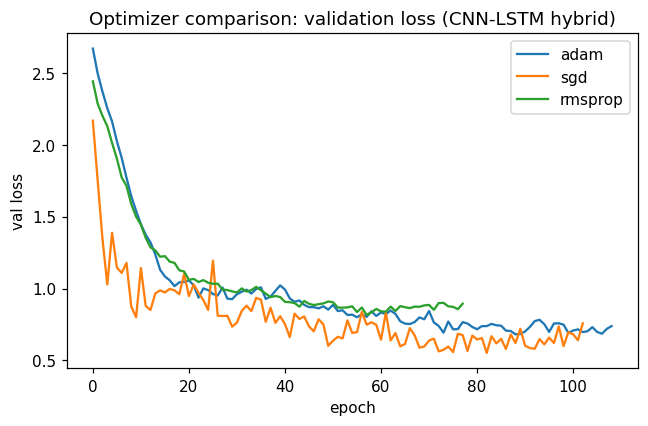

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
for opt_name, hist in optimizer_histories.items():
    ax.plot(hist.history["val_loss"], label=opt_name)
ax.set_xlabel("epoch")
ax.set_ylabel("val loss")
ax.set_title("Optimizer comparison: validation loss (CNN-LSTM hybrid)")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
opt_table = metrics_table(optimizer_results)
opt_table[opt_table.split == "test"].sort_values(["target", "R2"], ascending=[True, False]).reset_index(drop=True)

     model split target        R2      RMSE       MAE       KGE
0     adam  test    dbt  0.620486  1.395932  1.102948  0.674800
1  rmsprop  test    dbt  0.609832  1.415391  1.130504  0.558680
2      sgd  test    dbt  0.546272  1.526330  1.198930  0.614773
3  rmsprop  test    wbt  0.607678  0.574087  0.428377  0.731290
4      sgd  test    wbt  0.474160  0.664635  0.459135  0.807183
5     adam  test    wbt  0.456333  0.675807  0.480818  0.794041

## Keras Tuner: constrained search on the CNN-LSTM hybrid

Search space intentionally narrow (see `src/models.CNNLSTMHyperModel` docstring)
given only 46 validation rows to select against. `RandomSearch` with a small
trial budget, objective = val_loss, EarlyStopping inside every trial.


In [11]:
tuner = kt.RandomSearch(
    CNNLSTMHyperModel(input_shape),
    objective="val_loss",
    max_trials=20,
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_dir",
    project_name="cnn_lstm_search",
    seed=42,
)

y_train_dict = {"dbt": y_train[:, 0], "wbt": y_train[:, 1]}
y_val_dict = {"dbt": y_val[:, 0], "wbt": y_val[:, 1]}

tuner.search(
    X_train, y_train_dict, validation_data=(X_val, y_val_dict),
    epochs=150, batch_size=16, verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Best hyperparameters found:
  filters: 24
  kernel_size: 2
  lstm_units: 24
  dropout: 0.2
  l2: 0.001
  learning_rate: 0.001
  use_attention: False


In [12]:
tuned_model = tuner.hypermodel.build(best_hp)
ckpt = "models/checkpoints/cnn_lstm_tuned.keras"
hist_tuned = fit_model(tuned_model, ckpt, epochs=300)
best_tuned_model = tf.keras.models.load_model(ckpt)

tuned_results = {
    "train": evaluate_split(best_tuned_model, X_train, y_train),
    "val": evaluate_split(best_tuned_model, X_val, y_val),
    "test": evaluate_split(best_tuned_model, X_test, y_test),
}
print(f"Tuned model: {len(hist_tuned.history['loss'])} epochs, "
      f"best val_loss={min(hist_tuned.history['val_loss']):.4f}")
tuned_results["test"]

Tuned model: 71 epochs, best val_loss=0.7050


{'dbt': {'R2': 0.662331038294786, 'RMSE': 1.3167285676425702, 'MAE': 1.0405642930851426, 'KGE': np.float64(0.595157702499117)}, 'wbt': {'R2': 0.611307648448213, 'RMSE': 0.5714252036559389, 'MAE': 0.4130744490512582, 'KGE': np.float64(0.783099175595824)}}

## Final comparison: internship benchmark vs classical baselines (this split) vs DL models


In [13]:
with open("data/processed/baseline_results.pkl", "rb") as f:
    baseline = pickle.load(f)
baseline_table = baseline["table"]
best_classical = (baseline_table[baseline_table.split == "test"]
                   .sort_values(["target", "R2"], ascending=[True, False])
                   .groupby("target").first().reset_index())

final_rows = []
for target in ["dbt", "wbt"]:
    bench = INTERNSHIP_BENCHMARK[target]
    final_rows.append({"model": f"internship {bench['model']} (random split)", "target": target,
                        "R2": bench["R2"], "RMSE": bench["RMSE"], "MAE": bench["MAE"], "KGE": bench["KGE"]})
    bc = best_classical[best_classical.target == target].iloc[0]
    final_rows.append({"model": f"best classical, this split ({bc['model']})", "target": target,
                        "R2": bc.R2, "RMSE": bc.RMSE, "MAE": bc.MAE, "KGE": bc.KGE})
    for dl_name, dl_res in [("CNN-LSTM hybrid (default)", ablation_results["CNN-LSTM hybrid"]),
                             ("CNN-LSTM hybrid (tuned)", tuned_results)]:
        m = dl_res["test"][target]
        final_rows.append({"model": dl_name, "target": target, **m})

final_table = pd.DataFrame(final_rows)
final_table.to_csv("data/processed/final_comparison_table.csv", index=False)
final_table

                                        model target  ...       MAE       KGE
0             internship Ridge (random split)    dbt  ...  0.879200  0.781500
1  best classical, this split (Random Forest)    dbt  ...  0.947485  0.674949
2                   CNN-LSTM hybrid (default)    dbt  ...  1.318960  0.440003
3                     CNN-LSTM hybrid (tuned)    dbt  ...  1.040564  0.595158
4          internship LightGBM (random split)    wbt  ...  0.544200  0.747400
5    best classical, this split (Extra Trees)    wbt  ...  0.395698  0.786851
6                   CNN-LSTM hybrid (default)    wbt  ...  0.482962  0.773123
7                     CNN-LSTM hybrid (tuned)    wbt  ...  0.413074  0.783099

[8 rows x 6 columns]

In [14]:
with open("data/processed/dl_results.pkl", "wb") as f:
    pickle.dump({
        "ablation_results": ablation_results,
        "optimizer_results": optimizer_results,
        "tuned_results": tuned_results,
        "best_hyperparameters": best_hp.values,
        "gap_df": gap_df,
    }, f)
print("Saved dl_results.pkl")

Saved dl_results.pkl
